### Clean all the Powder Patch data from MesoWest - Synoptic Weather API

Notebook contents 
* loading all the data that I could download from Powder Patch (starting 2014 earliest) on the MesoWest (not Mesonet) Synoptic Weather API
* Making a copy of the `load..` notebook, and cleaning and smoothing the data here 

created by Cassie Lumbrazo\
last updated: July 2025\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib 

In [2]:
pwd

'/home/cassie/python/repos/snowdepth_teleconnections'

In [3]:
# save the df_snow_smooth dataframe to a csv file
# df_snow_smooth.to_csv('/home/cassie/python/repos/snowdepth_teleconnections/snow_depth_comparison_2015_2026.csv')

# load the saved csv file back into a dataframe
df_snow_smooth = pd.read_csv('/home/cassie/python/repos/snowdepth_teleconnections/snow_depth_comparison_2015_2026.csv', index_col=0, parse_dates=True)
df_snow_smooth.head()

,snotel,powderpatch,tram,snotel_smooth,powderpatch_smooth,tram_smooth
datetime,,,,,,
2015-10-01 00:00:00,0.0,NaN,4.33,0.0,NaN,4.268408
2015-10-01 01:00:00,0.0,NaN,4.33,0.0,NaN,4.261541
2015-10-01 02:00:00,0.0,NaN,4.33,0.0,NaN,4.254677
2015-10-01 03:00:00,0.0,NaN,4.33,0.0,NaN,4.247814
2015-10-01 04:00:00,0.0,NaN,4.72,0.0,NaN,4.240953


In [4]:
df = df_snow_smooth.copy(deep=True)

In [5]:
# Step 1: Compute water year (1 Sept - 31 Aug)
df['datetime'] = pd.to_datetime(df.index)  # Ensure datetime
df['water_year'] = df['datetime'].apply(
    lambda d: d.year + 1 if d.month >= 9 else d.year
)

df

,snotel,powderpatch,tram,snotel_smooth,powderpatch_smooth,tram_smooth,datetime,water_year
datetime,,,,,,,,
2015-10-01 00:00:00,0.0,NaN,4.33,0.0,NaN,4.268408,2015-10-01 00:00:00,2016
2015-10-01 01:00:00,0.0,NaN,4.33,0.0,NaN,4.261541,2015-10-01 01:00:00,2016
2015-10-01 02:00:00,0.0,NaN,4.33,0.0,NaN,4.254677,2015-10-01 02:00:00,2016
2015-10-01 03:00:00,0.0,NaN,4.33,0.0,NaN,4.247814,2015-10-01 03:00:00,2016
2015-10-01 04:00:00,0.0,NaN,4.72,0.0,NaN,4.240953,2015-10-01 04:00:00,2016
...,...,...,...,...,...,...,...,...
2026-03-20 05:00:00,NaN,98.54,NaN,NaN,91.674162,NaN,2026-03-20 05:00:00,2026
2026-03-20 06:00:00,NaN,98.82,NaN,NaN,91.689833,NaN,2026-03-20 06:00:00,2026
2026-03-20 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-20 07:00:00,2026


In [6]:
# # Step 2: Define water year max thresholds
# wy_max_depth = {
#     2012: 600, # mesonet only, not great 
#     2013: 600, # mesonet only, not great 
#     2014: 600, # mesonet only, not great 
#     2015: 600, # mesonet only, not great 
#     2016: 250,
#     2017: 350,
#     2018: 350,
#     2019: 250,
#     2020: 450, # the data for this year is pretty tough, might need to remove a lot.. come back to this value 
#     2021: 500,
#     2022: 500,
#     2023: 400,
#     2024: 400,
#     2025: 250,
# }

# # Step 3: Clean snow depth columns based on water year-specific max
# for col in ['hs_clean']:
#     if col in df.columns:
#         df[col] = df.apply(
#             lambda row: row[col] if (0 <= row[col] <= wy_max_depth.get(row['water_year'], 450)) else None,
#             axis=1
#         )

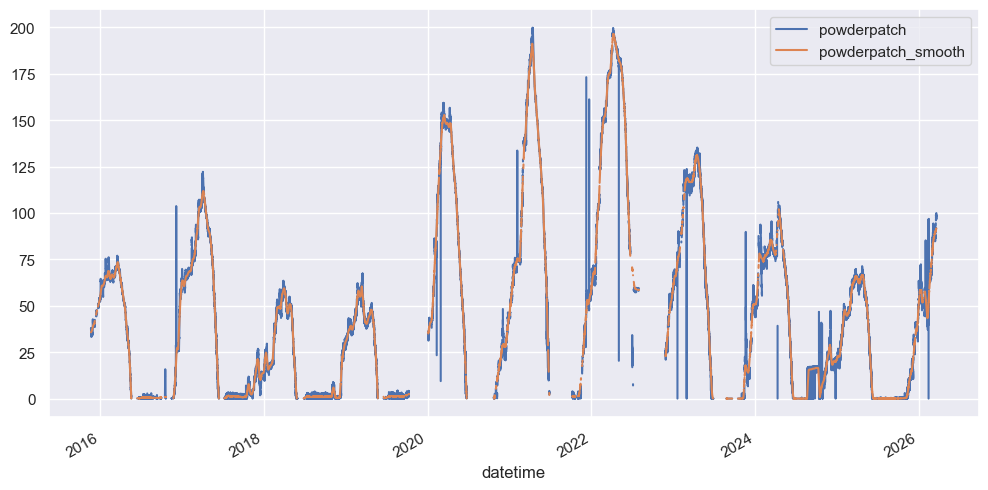

In [7]:
df['powderpatch'].plot()
df['powderpatch_smooth'].plot()

plt.legend(['powderpatch', 'powderpatch_smooth'])

In [8]:
# Compute water_doy (Day of Water Year starting Sept 1)
def compute_water_doy(dt):
    wy_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - wy_start).days + 1

df['water_doy'] = df['datetime'].apply(compute_water_doy)
df.head()

,snotel,powderpatch,tram,snotel_smooth,powderpatch_smooth,tram_smooth,datetime,water_year,water_doy
datetime,,,,,,,,,
2015-10-01 00:00:00,0.0,NaN,4.33,0.0,NaN,4.268408,2015-10-01 00:00:00,2016,31
2015-10-01 01:00:00,0.0,NaN,4.33,0.0,NaN,4.261541,2015-10-01 01:00:00,2016,31
2015-10-01 02:00:00,0.0,NaN,4.33,0.0,NaN,4.254677,2015-10-01 02:00:00,2016,31
2015-10-01 03:00:00,0.0,NaN,4.33,0.0,NaN,4.247814,2015-10-01 03:00:00,2016,31
2015-10-01 04:00:00,0.0,NaN,4.72,0.0,NaN,4.240953,2015-10-01 04:00:00,2016,31


In [9]:
# Compute water year
df['water_year'] = df['datetime'].apply(lambda d: d.year + 1 if d.month >= 10 else d.year)

# Compute start datetime of each row's water year
df['water_year_start'] = df['water_year'].apply(lambda wy: pd.Timestamp(f"{wy-1}-10-01"))

# Compute continuous time axis: days since start of first water year
first_water_year_start = df['water_year_start'].min()
df['day_since_first_wy'] = (df['datetime'] - first_water_year_start).dt.days

# Drop missing data
# df = df.dropna(subset=['hs_clean', 'day_since_first_wy'])
df

,snotel,powderpatch,tram,snotel_smooth,powderpatch_smooth,tram_smooth,datetime,water_year,water_doy,water_year_start,day_since_first_wy
datetime,,,,,,,,,,,
2015-10-01 00:00:00,0.0,NaN,4.33,0.0,NaN,4.268408,2015-10-01 00:00:00,2016,31,2015-10-01,0
2015-10-01 01:00:00,0.0,NaN,4.33,0.0,NaN,4.261541,2015-10-01 01:00:00,2016,31,2015-10-01,0
2015-10-01 02:00:00,0.0,NaN,4.33,0.0,NaN,4.254677,2015-10-01 02:00:00,2016,31,2015-10-01,0
2015-10-01 03:00:00,0.0,NaN,4.33,0.0,NaN,4.247814,2015-10-01 03:00:00,2016,31,2015-10-01,0
2015-10-01 04:00:00,0.0,NaN,4.72,0.0,NaN,4.240953,2015-10-01 04:00:00,2016,31,2015-10-01,0
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20 05:00:00,NaN,98.54,NaN,NaN,91.674162,NaN,2026-03-20 05:00:00,2026,201,2025-10-01,3823
2026-03-20 06:00:00,NaN,98.82,NaN,NaN,91.689833,NaN,2026-03-20 06:00:00,2026,201,2025-10-01,3823
2026-03-20 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-20 07:00:00,2026,201,2025-10-01,3823


In [10]:
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df['pp_smooth_001'] = lowess(
    endog=df['powderpatch'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df['pp_smooth_002'] = lowess(
    endog=df['powderpatch'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df['pp_smooth_005'] = lowess(
    endog=df['powderpatch'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

In [11]:
# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df['heen_smooth_001'] = lowess(
    endog=df['snotel'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df['heen_smooth_002'] = lowess(
    endog=df['snotel'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df['heen_smooth_005'] = lowess(
    endog=df['snotel'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

In [12]:
# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df['tram_smooth_001'] = lowess(
    endog=df['tram'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df['tram_smooth_002'] = lowess(
    endog=df['tram'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df['tram_smooth_005'] = lowess(
    endog=df['tram'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

## Plotting..

In [13]:
def get_snow_year_day(dt):
    snow_year_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - snow_year_start).days

df['snow_year_day'] = df.index.map(get_snow_year_day)

add a black trend line... 

Adjust alpha, make the lines gray?

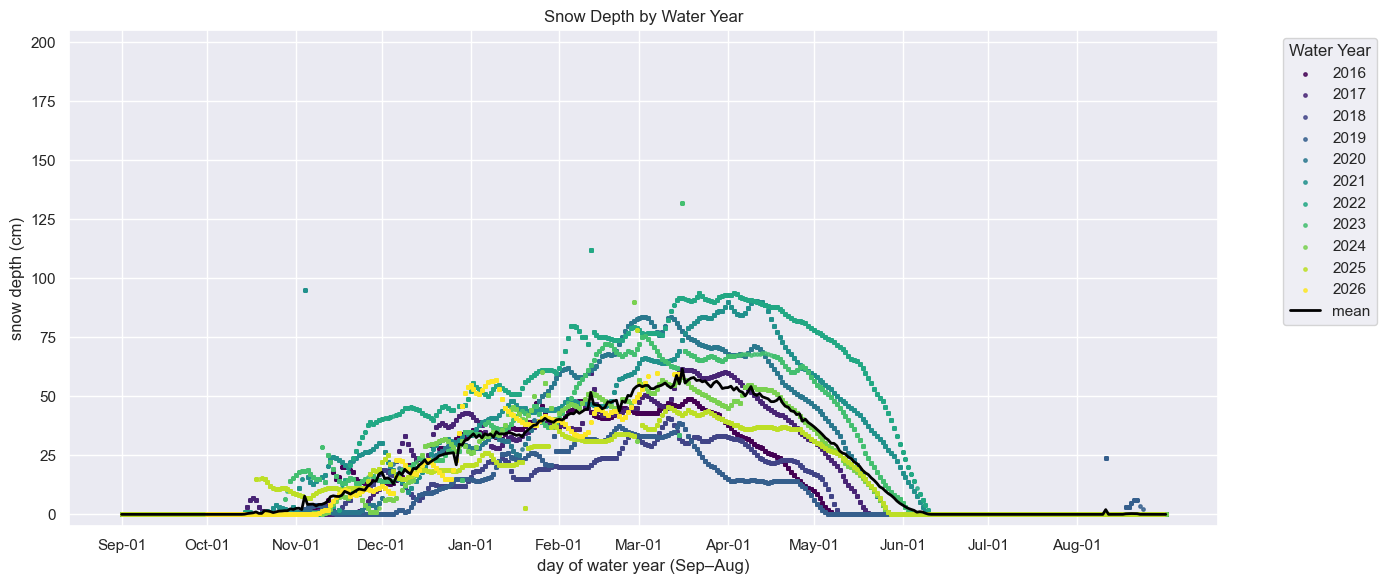

In [14]:
depth_col = 'heen_smooth_001'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.8,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

#set the y-axis limits
plt.ylim(-5, 205)

plt.tight_layout()
plt.show()

In [15]:
from matplotlib.lines import Line2D

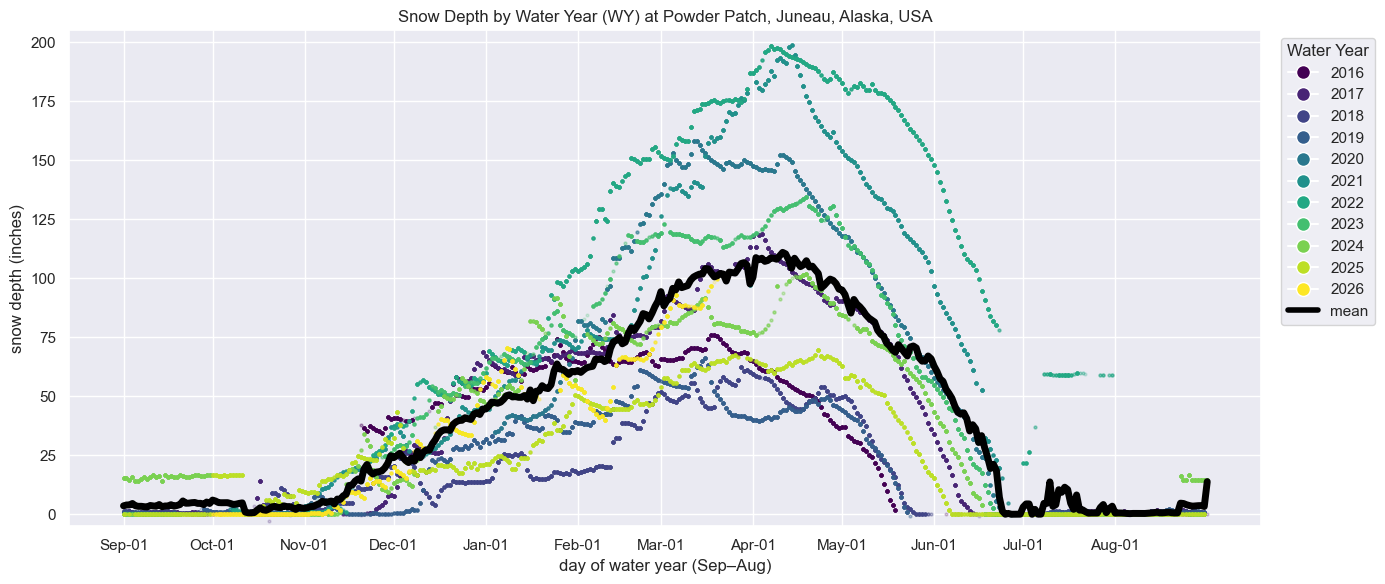

In [34]:
depth_col = 'pp_smooth_001'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.2,
        s=4
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (inches)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year (WY) at Powder Patch, Juneau, Alaska, USA')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=5,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
# plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

# Create custom legend handles
legend_elements = [
    Line2D(
        [0], [0], 
        marker='o', 
        color='w', 
        label=str(year), 
        markerfacecolor=cmap(norm(year)), 
        markersize=10  # 👈 Increase this value for larger dots
    )
    for year in water_years
]

# Add 'mean' line to the legend
legend_elements.append(
    Line2D(
        [0], [0], 
        color='black', 
        lw=4, 
        label='mean'
    )
)

# Show legend with custom handles
plt.legend(
    handles=legend_elements, 
    title='Water Year',
    bbox_to_anchor=(1.01, 1), 
    loc='upper left'
)

#set the y-axis limits
plt.ylim(-5, 205)

plt.tight_layout()
plt.show()

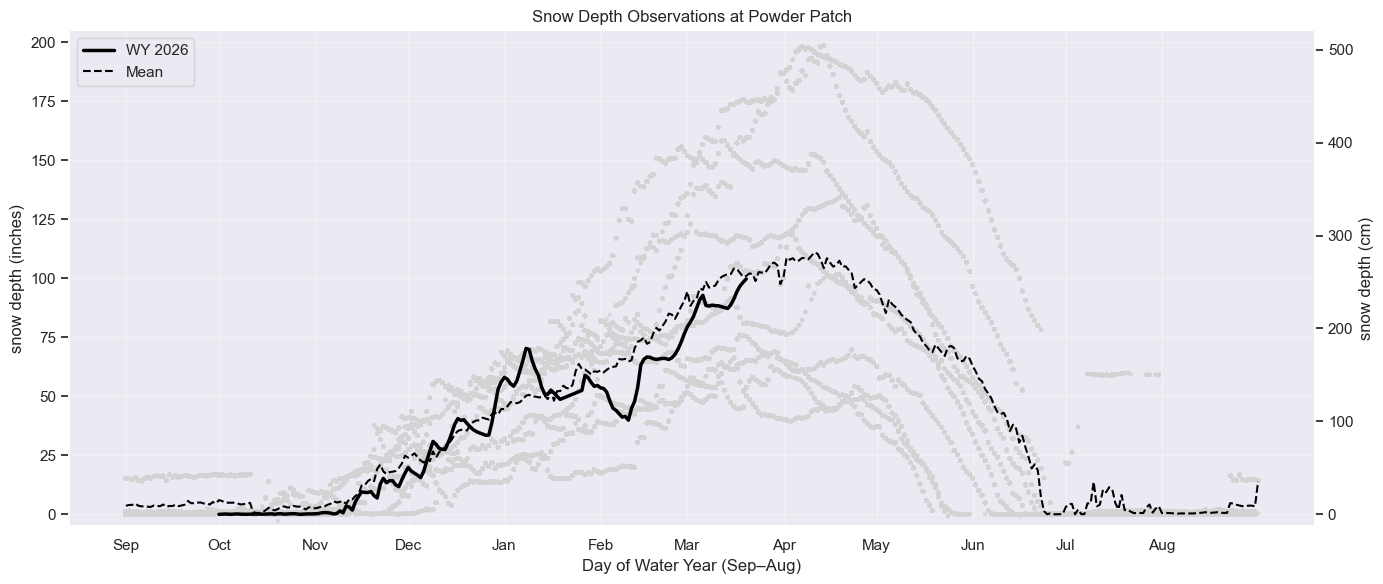

In [47]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

depth_col = 'pp_smooth_001'

# -----------------------------
# Prepare data
# -----------------------------
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

water_years = sorted(df_plot['water_year'].unique())

# Identify target WY (latest assumed = 2026)
target_wy = max(water_years)

# Colormap (more readable than viridis for this use case)
# cmap = matplotlib.colormaps.get_cmap('cividis')
# norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))

# -----------------------------
# Figure + axes
# -----------------------------
fig, ax_in = plt.subplots(figsize=(14, 6))

# -----------------------------
# Background years (grey cloud)
# -----------------------------
for year in water_years:
    if year == target_wy:
        continue

    year_data = df_plot[df_plot['water_year'] == year]

    ax_in.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        color='lightgrey',
        alpha=0.8,     # ↓ key for readability
        s=10,            # slightly larger than 2 for visibility
        edgecolors='none'
    )

# -----------------------------
# Highlight WY 2026
# -----------------------------
year_data = df_plot[df_plot['water_year'] == target_wy]

ax_in.plot(
    year_data['snow_year_day'],
    year_data[depth_col],
    color='black',
    linewidth=2.5,
    label=f'WY {target_wy}'
)

# -----------------------------
# Mean line (dashed, subtle)
# -----------------------------
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

ax_in.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Mean'
)

# -----------------------------
# X-axis formatting
# -----------------------------
tick_locs = []
tick_labels = []

for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b'))

for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b'))

ax_in.set_xticks(tick_locs)
ax_in.set_xticklabels(tick_labels)

# -----------------------------
# Y-axis (RIGHT: inches)
# -----------------------------
ax_in.set_ylabel('snow depth (inches)')
ax_in.set_ylim(-5, 205)

# -----------------------------
# Y-axis (LEFT: cm)
# -----------------------------
ax_cm = ax_in.twinx()

inch_to_cm = 2.54
ymin, ymax = ax_in.get_ylim()

ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
ax_cm.set_ylabel('snow depth (cm)')

# Move cm axis to LEFT
ax_cm.yaxis.set_label_position('right')
ax_cm.yaxis.tick_right()
ax_in.yaxis.tick_left()
ax_in.yaxis.set_label_position('left')

# remove the second gridlines 
ax_cm.grid(False)

# -----------------------------
# Styling
# -----------------------------
ax_in.set_xlabel('Day of Water Year (Sep–Aug)')
ax_in.set_title('Snow Depth Observations at Powder Patch')

ax_in.grid(True, alpha=0.3)

# -----------------------------
# Legend (clean + minimal)
# -----------------------------
legend_elements = [
    Line2D([0], [0], color='black', lw=2.5, label=f'WY {target_wy}'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Mean')
]

ax_in.legend(
    handles=legend_elements,
    loc='upper left'
)

plt.tight_layout()
plt.show()

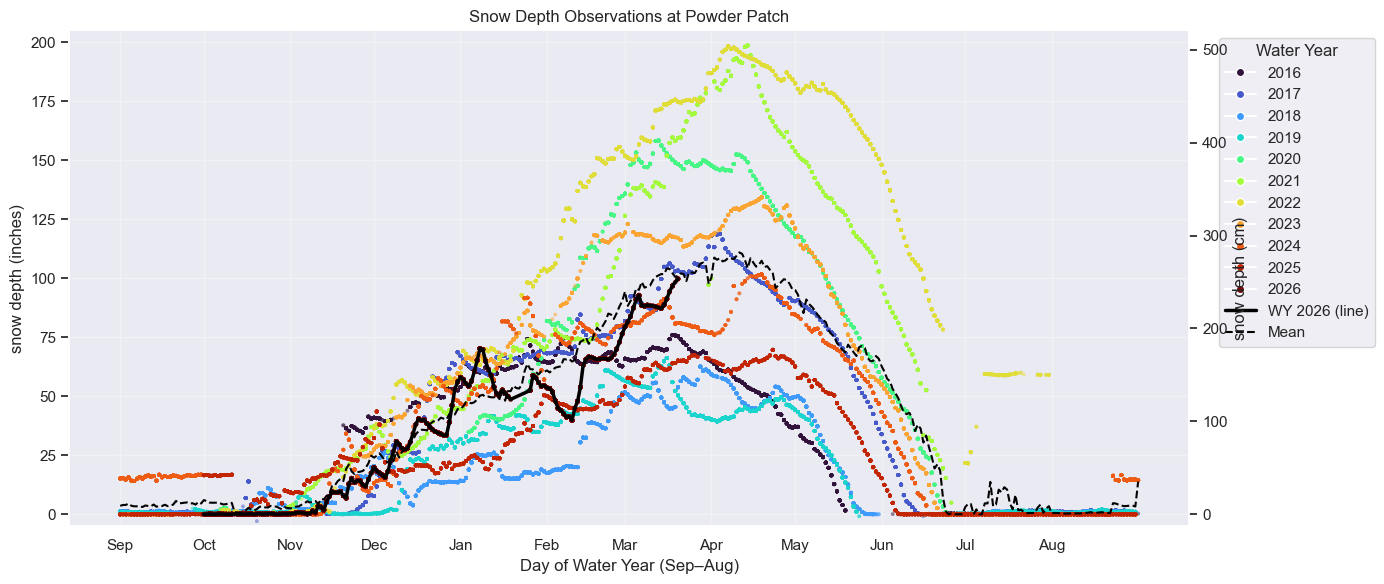

In [48]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

depth_col = 'pp_smooth_001'

# -----------------------------
# Prepare data
# -----------------------------
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

water_years = sorted(df_plot['water_year'].unique())

# Identify target WY (latest assumed = 2026)
target_wy = max(water_years)

# Colormap (more readable than viridis for this use case)
# cmap = matplotlib.colormaps.get_cmap('cividis')
# norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))

# -----------------------------
# Figure + axes
# -----------------------------
fig, ax_in = plt.subplots(figsize=(14, 6))

# -----------------------------
# Background years (grey cloud)
# -----------------------------
# -----------------------------
# Colormap setup
# -----------------------------
cmap = matplotlib.colormaps.get_cmap('turbo')  # vivid but readable
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))

# -----------------------------
# Plot ALL years with colors
# -----------------------------
legend_elements = []

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))

    # Slightly emphasize recent years (optional but useful)
    alpha = 0.7 if year == target_wy else 0.5
    size = 12 if year == target_wy else 8

    ax_in.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        color=color,
        alpha=alpha,
        s=size,
        edgecolors='none'
    )

    # Add to legend
    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=str(year),
            markerfacecolor=color,
            markersize=6
        )
    )

# -----------------------------
# Highlight WY 2026
# -----------------------------
year_data = df_plot[df_plot['water_year'] == target_wy]

ax_in.plot(
    year_data['snow_year_day'],
    year_data[depth_col],
    color='black',
    linewidth=2.5,
    label=f'WY {target_wy}'
)

# -----------------------------
# Mean line (dashed, subtle)
# -----------------------------
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

ax_in.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Mean'
)

# -----------------------------
# X-axis formatting
# -----------------------------
tick_locs = []
tick_labels = []

for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b'))

for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b'))

ax_in.set_xticks(tick_locs)
ax_in.set_xticklabels(tick_labels)

# -----------------------------
# Y-axis (RIGHT: inches)
# -----------------------------
ax_in.set_ylabel('snow depth (inches)')
ax_in.set_ylim(-5, 205)

# -----------------------------
# Y-axis (LEFT: cm)
# -----------------------------
ax_cm = ax_in.twinx()

inch_to_cm = 2.54
ymin, ymax = ax_in.get_ylim()

ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
ax_cm.set_ylabel('snow depth (cm)')

# Move cm axis to LEFT
ax_cm.yaxis.set_label_position('right')
ax_cm.yaxis.tick_right()
ax_in.yaxis.tick_left()
ax_in.yaxis.set_label_position('left')

# remove the second gridlines 
ax_cm.grid(False)

# -----------------------------
# Styling
# -----------------------------
ax_in.set_xlabel('Day of Water Year (Sep–Aug)')
ax_in.set_title('Snow Depth Observations at Powder Patch')

ax_in.grid(True, alpha=0.3)

# -----------------------------
# Legend (clean + minimal)
# -----------------------------
# Add mean + WY line styles to legend
legend_elements.extend([
    Line2D([0], [0], color='black', lw=2.5, label=f'WY {target_wy} (line)'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Mean')
])

ax_in.legend(
    handles=legend_elements,
    title='Water Year',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    ncol=1
)

plt.tight_layout()
plt.show()

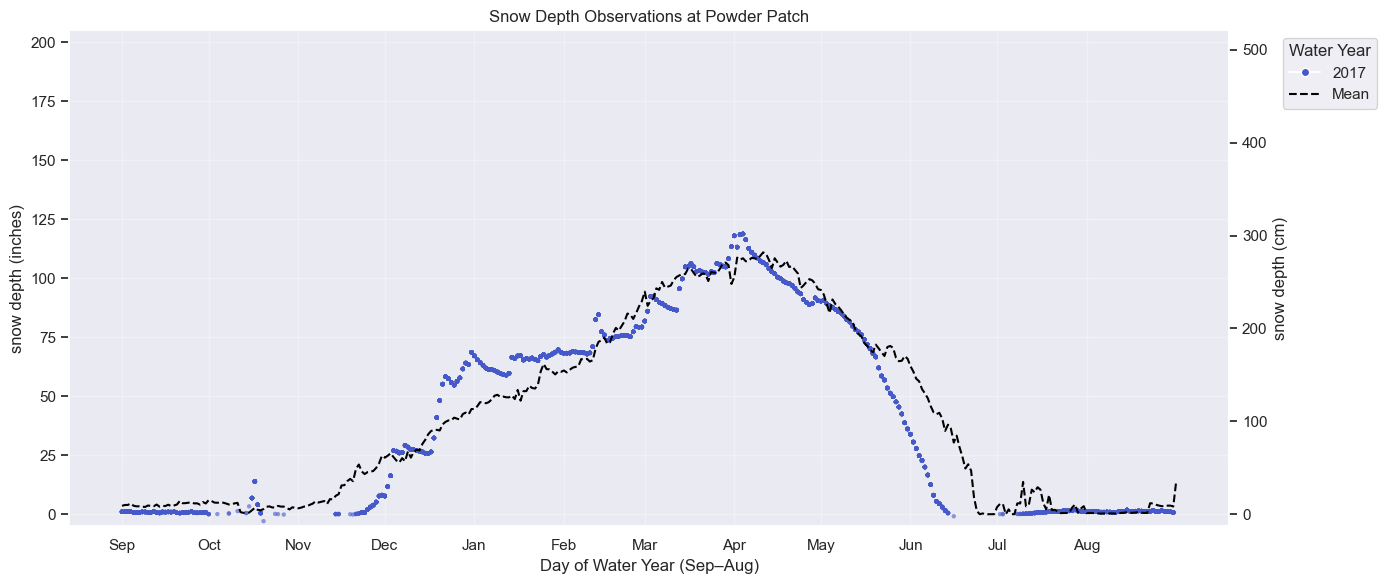

In [60]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# All years (full dataset, NOT subset)
all_years = sorted(df['water_year'].dropna().unique())

# Fixed normalization across ALL years
cmap = matplotlib.colormaps.get_cmap('turbo')
norm = mcolors.Normalize(vmin=min(all_years), vmax=max(all_years))

# Create a persistent mapping
year_color_map = {year: cmap(norm(year)) for year in all_years}

depth_col = 'pp_smooth_001'

# -----------------------------
# Prepare data
# -----------------------------
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

water_years = sorted(df_plot['water_year'].unique())

# Identify target WY (latest assumed = 2026)
target_wy = max(water_years)

# Colormap (more readable than viridis for this use case)
# cmap = matplotlib.colormaps.get_cmap('cividis')
# norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))

# -----------------------------
# Figure + axes
# -----------------------------
fig, ax_in = plt.subplots(figsize=(14, 6))

# -----------------------------
# Background years (grey cloud)
# -----------------------------
# -----------------------------
# Colormap setup
# -----------------------------
cmap = matplotlib.colormaps.get_cmap('turbo')  # vivid but readable
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))

# -----------------------------
# Plot ALL years with colors
# -----------------------------

# years_to_plot = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]  # change this as needed
years_to_plot = [2017]  # change this as needed

legend_elements = []

for year in years_to_plot:
    year_data = df_plot[df_plot['water_year'] == year]
    # color = cmap(norm(year))
    color = year_color_map[year]   # ← KEY CHANGE

    ax_in.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        color=color,
        alpha=0.6,
        s=10,
        edgecolors='none'
    )

    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=str(year),
            markerfacecolor=color,
            markersize=6
        )
    )

# -----------------------------
# Highlight WY 2026
# -----------------------------
# year_data = df_plot[df_plot['water_year'] == target_wy]

# ax_in.plot(
#     year_data['snow_year_day'],
#     year_data[depth_col],
#     color='black',
#     linewidth=2.5,
#     label=f'WY {target_wy}'
# )

# -----------------------------
# Mean line (dashed, subtle)
# -----------------------------
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

ax_in.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Mean'
)

# -----------------------------
# X-axis formatting
# -----------------------------
tick_locs = []
tick_labels = []

for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b'))

for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b'))

ax_in.set_xticks(tick_locs)
ax_in.set_xticklabels(tick_labels)

# -----------------------------
# Y-axis (RIGHT: inches)
# -----------------------------
ax_in.set_ylabel('snow depth (inches)')
ax_in.set_ylim(-5, 205)

# -----------------------------
# Y-axis (LEFT: cm)
# -----------------------------
ax_cm = ax_in.twinx()

inch_to_cm = 2.54
ymin, ymax = ax_in.get_ylim()

ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
ax_cm.set_ylabel('snow depth (cm)')

# Move cm axis to LEFT
ax_cm.yaxis.set_label_position('right')
ax_cm.yaxis.tick_right()
ax_in.yaxis.tick_left()
ax_in.yaxis.set_label_position('left')

# remove the second gridlines 
ax_cm.grid(False)

# -----------------------------
# Styling
# -----------------------------
ax_in.set_xlabel('Day of Water Year (Sep–Aug)')
ax_in.set_title('Snow Depth Observations at Powder Patch')

ax_in.grid(True, alpha=0.3)

# -----------------------------
# Legend (clean + minimal)
# -----------------------------
# Add mean + WY line styles to legend
legend_elements.extend([
    # Line2D([0], [0], color='black', lw=2.5, label=f'WY {target_wy} (line)'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Mean')
])

ax_in.legend(
    handles=legend_elements,
    title='Water Year',
    bbox_to_anchor=(1.04, 1),
    loc='upper left',
    ncol=1
)

plt.tight_layout()
plt.show()

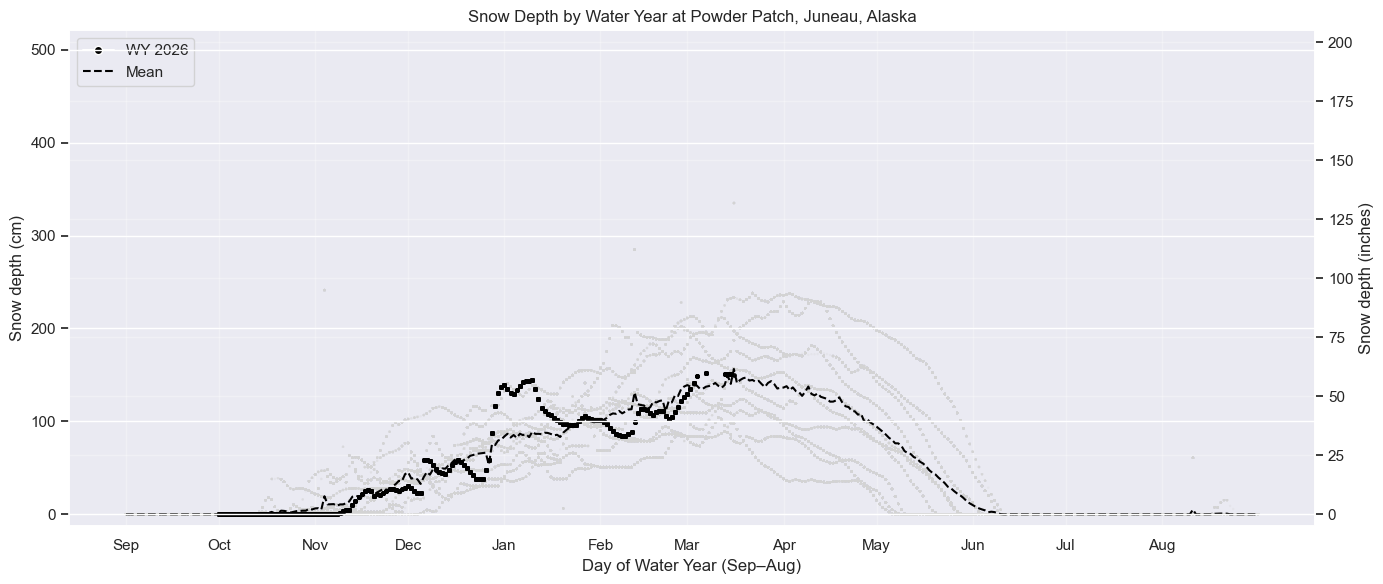

In [ ]:
depth_col = 'heen_smooth_001'

# -----------------------------
# Prepare data
# -----------------------------
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()
water_years = sorted(df_plot['water_year'].unique())

target_wy = max(water_years)  # assume 2026

# -----------------------------
# Figure + axes
# -----------------------------
fig, ax_in = plt.subplots(figsize=(14, 6))

# -----------------------------
# Background years (grey cloud)
# -----------------------------
for year in water_years:
    if year == target_wy:
        continue

    year_data = df_plot[df_plot['water_year'] == year]

    ax_in.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        color='lightgrey',
        alpha=0.25,     # ↓ key for readability
        s=3,            # slightly larger than 2 for visibility
        edgecolors='none'
    )

# -----------------------------
# Highlight WY 2026
# -----------------------------
year_data = df_plot[df_plot['water_year'] == target_wy]

ax_in.scatter(
    year_data['snow_year_day'],
    year_data[depth_col],
    color='black',
    alpha=0.9,
    s=6,
    label=f'WY {target_wy}',
    zorder=5   # ensures it's on top
)

# -----------------------------
# Mean line (dashed)
# -----------------------------
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

ax_in.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Mean',
    zorder=6
)

# -----------------------------
# X-axis formatting
# -----------------------------
tick_locs = []
tick_labels = []

for month in range(9, 13):
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b'))

for month in range(1, 9):
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b'))

ax_in.set_xticks(tick_locs)
ax_in.set_xticklabels(tick_labels)

# -----------------------------
# Y-axis (RIGHT: inches)
# -----------------------------
ax_in.set_ylabel('Snow depth (inches)')
ax_in.set_ylim(-5, 205)

# -----------------------------
# Y-axis (LEFT: cm)
# -----------------------------
ax_cm = ax_in.twinx()

inch_to_cm = 2.54
ymin, ymax = ax_in.get_ylim()

ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
ax_cm.set_ylabel('Snow depth (cm)')

# Move cm axis to LEFT
ax_cm.yaxis.set_label_position('left')
ax_cm.yaxis.tick_left()
ax_in.yaxis.tick_right()
ax_in.yaxis.set_label_position('right')

# -----------------------------
# Styling
# -----------------------------
ax_in.set_xlabel('Day of Water Year (Sep–Aug)')
ax_in.set_title('Snow Depth by Water Year at Powder Patch, Juneau, Alaska')

ax_in.grid(True, alpha=0.3)

# -----------------------------
# Legend (minimal + clean)
# -----------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
           markersize=6, label=f'WY {target_wy}'),
    Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='Mean')
]

ax_in.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

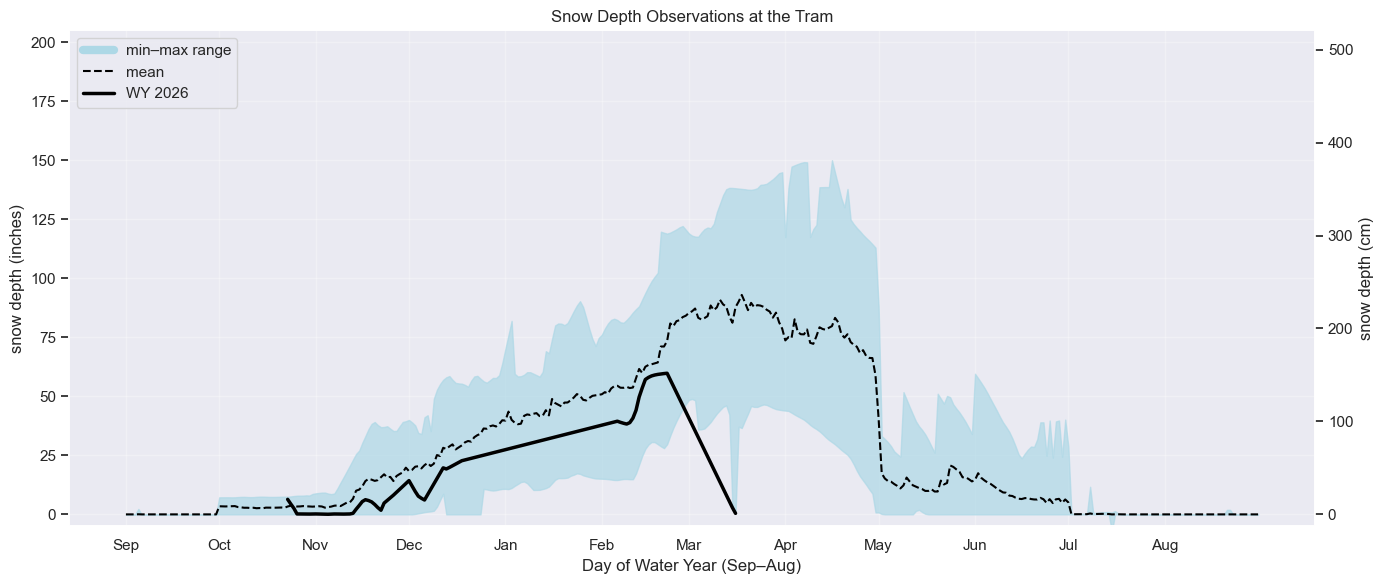

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

depth_col = 'tram_smooth_002'

# -----------------------------
# Prepare data
# -----------------------------
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()
water_years = sorted(df_plot['water_year'].unique())

target_wy = max(water_years)

# -----------------------------
# Aggregate stats by day
# -----------------------------
grouped = df_plot.groupby('snow_year_day')[depth_col]

min_by_day = grouped.min().sort_index()
max_by_day = grouped.max().sort_index()
mean_by_day = grouped.mean().sort_index()

# -----------------------------
# Figure + axes
# -----------------------------
fig, ax_in = plt.subplots(figsize=(14, 6))

# -----------------------------
# Fill min–max envelope
# -----------------------------
ax_in.fill_between(
    min_by_day.index,
    min_by_day.values,
    max_by_day.values,
    color='lightblue',
    alpha=0.7,
    label='min–max range'
)

# -----------------------------
# Mean line (dashed, subtle)
# -----------------------------
ax_in.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='mean'
)

# -----------------------------
# Current WY (solid, emphasized)
# -----------------------------
year_data = df_plot[df_plot['water_year'] == target_wy]

ax_in.plot(
    year_data['snow_year_day'],
    year_data[depth_col],
    color='black',
    linewidth=2.5,
    label=f'WY {target_wy}'
)

# -----------------------------
# X-axis formatting
# -----------------------------
tick_locs = []
tick_labels = []

for month in range(9, 13):
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b'))

for month in range(1, 9):
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b'))

ax_in.set_xticks(tick_locs)
ax_in.set_xticklabels(tick_labels)

# -----------------------------
# Y-axis (RIGHT: inches)
# -----------------------------
ax_in.set_ylabel('snow depth (inches)')
ax_in.set_ylim(-5, 205)

# -----------------------------
# Y-axis (LEFT: cm)
# -----------------------------
ax_cm = ax_in.twinx()

inch_to_cm = 2.54
ymin, ymax = ax_in.get_ylim()

ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
ax_cm.set_ylabel('snow depth (cm)')

# Move cm axis to LEFT
ax_cm.yaxis.set_label_position('right')
ax_cm.yaxis.tick_right()
ax_in.yaxis.tick_left()
ax_in.yaxis.set_label_position('left')

# remove the second gridlines
ax_cm.grid(False)

# -----------------------------
# Styling
# -----------------------------
ax_in.set_xlabel('Day of Water Year (Sep–Aug)')
ax_in.set_title('Snow Depth Observations at the Tram')

ax_in.grid(True, alpha=0.3)

# -----------------------------
# Legend (clean)
# -----------------------------
legend_elements = [
    Line2D([0], [0], color='lightblue', lw=6, label='min–max range'),
    Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='mean'),
    Line2D([0], [0], color='black', lw=2.5, label=f'WY {target_wy}')
]

ax_in.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

Messing with plotting, 

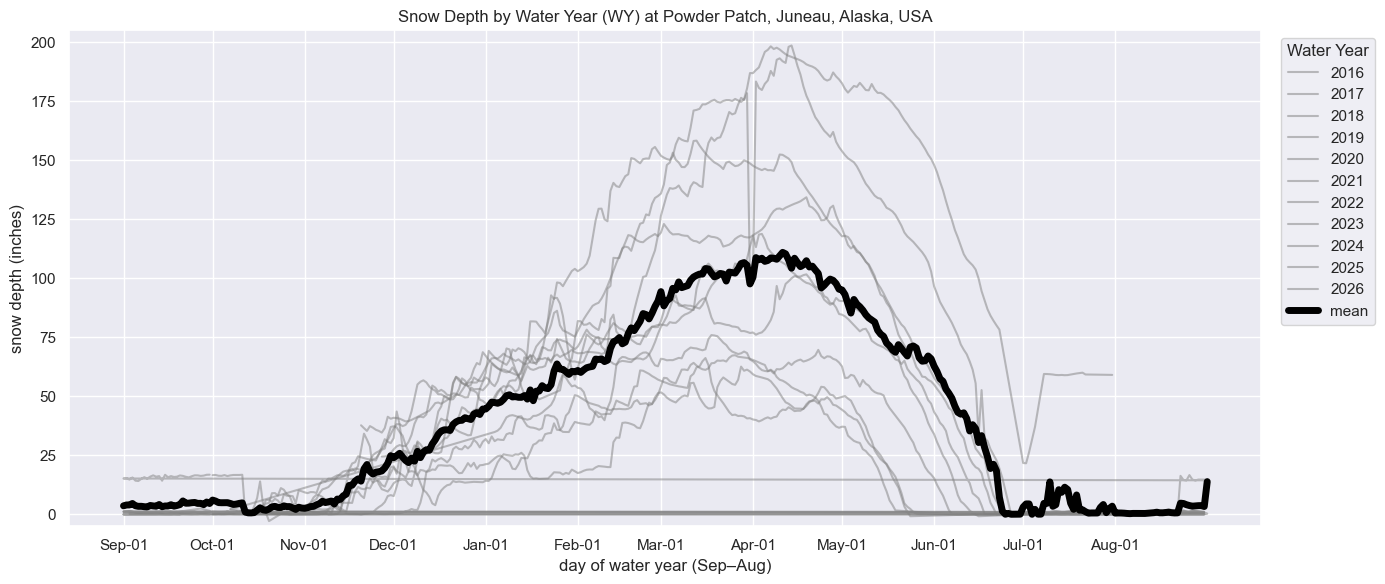

In [21]:
depth_col = 'pp_smooth_001'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    plt.plot(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color='grey',
        alpha=0.5,
        # s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (inches)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
# plt.title('Snow Depth by Water Year (Data: smoothed)')
plt.title('Snow Depth by Water Year (WY) at Powder Patch, Juneau, Alaska, USA')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=5,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
plt.legend(title='Water Year', bbox_to_anchor=(1.01, 1), loc='upper left')

#set the y-axis limits
plt.ylim(-5, 205)

plt.tight_layout()
plt.show()